In [1]:
import pybedtools
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import numpy as np
import os
import scipy.stats as stats

In [54]:
# necessary for creating plotly figs and saving as static images
#!pip install plotly
#!pip install nbformat
#!pip install kaleido

In [ ]:

# ==============================================================================
# PARAMETERS & FILE PATHS - FILL THESE IN
# ==============================================================================

# 1. Provide the paths to your RAW narrowPeak files
PEAKS_DIR="/nfs/turbo/umms-hammou/mrabbani/DATA_STORAGE/Cut_Tag/A8538/25950R_histone/Peaks"
stage_peak_files=[PEAKS_DIR + "/D32_RS_H3K27me3.narrowPeak", #late_RS    47767 peaks
                PEAKS_DIR + "/D34_RS_H3K27me3.narrowPeak", #early_ES_2 27519 peaks
                PEAKS_DIR + "/D34_SNF2H_RS_H3K27me3.narrowPeak", #early_RS 29829 peaks
                PEAKS_DIR + "/D34_SNF2H_ES_H3K27me3.narrowPeak"] #int_ES 56310 peaks

raw_h3_files = {
    'Early RS': stage_peak_files[2],
    'Late RS': stage_peak_files[0],
    'Early ES': stage_peak_files[1],
    'Int ES': stage_peak_files[3]
}


ATAC_DIR="/nfs/turbo/umms-hammou/mrabbani/DATA_STORAGE/ATAC-processed/Tim_Parnell_analysis/Mashiat_analysis/ATAC_alldatasets/macs_peaks_all_atac"
ATAC_files=[ATAC_DIR + "/all_late_RS_narrowpeaks.sorted.merged.bed", #late_RS    
                ATAC_DIR + "/all_early_ES_narrowpeaks.sorted.merged.bed", #early_ES
                ATAC_DIR + "/all_early_RS_narrowpeaks.sorted.merged.bed", #early_RS
                ATAC_DIR + "/all_int_ES_narrowpeaks.sorted.merged.bed" #int_ES
]

raw_atac_files = {
    'Early RS': ATAC_files[2],
    'Late RS': ATAC_files[0],
    'Early ES': ATAC_files[1],
    'Int ES': ATAC_files[3]
}

# 2. Output directory for the merged files
OUTPUT_DIR = '/nfs/turbo/umms-hammou/minjilab/juicer/analysis_data/merged_peaks/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 3. Set merge distances (in base pairs)
H3_MERGE_DIST = 2000
# smaller gap for ATAC to preserve distinct regulatory elements
ATAC_MERGE_DIST = 100 

# ==============================================================================
# MERGING FUNCTION
# ==============================================================================

def sort_and_merge_peaks(input_files_dict, mark_name, merge_distance):
    print(f"Processing {mark_name} with merge distance -d {merge_distance}...")
    
    # Dictionary to hold the paths of the newly created merged files
    merged_output_paths = {}
    
    for stage, filepath in input_files_dict.items():
        print(f"  Sorting and merging {stage}...")
        
        # Define the output filename
        out_filename = os.path.join(OUTPUT_DIR, f"{mark_name}_{stage}_merged_d{merge_distance}.bed")
        
        # Load the raw narrowPeak file
        raw_bed = pybedtools.BedTool(filepath)
        
        # Chain the commands: sort() then merge(d=distance)
        # Using saveas() writes the output to disk so it can be fed into your downstream scripts
        merged_bed = raw_bed.sort().merge(d=merge_distance).saveas(out_filename)
        
        # Store the path for the next steps of your pipeline
        merged_output_paths[stage] = out_filename
        
    print(f"Done merging {mark_name}.\n")
    return merged_output_paths

# ==============================================================================
# EXECUTE
# ==============================================================================

# Run the merge for H3K27me3
merged_h3_files = sort_and_merge_peaks(raw_h3_files, 'H3K27me3', H3_MERGE_DIST)

# Run the merge for ATAC-seq
merged_atac_files = sort_and_merge_peaks(raw_atac_files, 'ATAC-seq', ATAC_MERGE_DIST)

Processing H3K27me3 with merge distance -d 2000...
  Sorting and merging Early RS...
  Sorting and merging Late RS...
  Sorting and merging Early ES...
  Sorting and merging Int ES...
Done merging H3K27me3.

Processing ATAC-seq with merge distance -d 100...
  Sorting and merging Early RS...
  Sorting and merging Late RS...
  Sorting and merging Early ES...
  Sorting and merging Int ES...
Done merging ATAC-seq.



In [3]:
# get number of peaks in each merged file for sanity check
for stage, path in merged_h3_files.items():
    num_peaks = sum(1 for _ in open(path))
    print(f"{stage} H3K27me3 merged peaks: {num_peaks}")
for stage, path in merged_atac_files.items():
    num_peaks = sum(1 for _ in open(path))
    print(f"{stage} ATAC-seq merged peaks: {num_peaks}")


Early RS H3K27me3 merged peaks: 10270
Late RS H3K27me3 merged peaks: 20127
Early ES H3K27me3 merged peaks: 12652
Int ES H3K27me3 merged peaks: 35693
Early RS ATAC-seq merged peaks: 210398
Late RS ATAC-seq merged peaks: 245431
Early ES ATAC-seq merged peaks: 334969
Int ES ATAC-seq merged peaks: 444472


In [3]:

other_h3k = [PEAKS_DIR + "/D32_ES_H3K27me3.narrowPeak", #early_ES_1 4968 peaks
             PEAKS_DIR + "/D34_ES_H3K27me3.narrowPeak"] #earliest_ES 3142 peaks
raw_h3_other_files = {
    'Early ES2': other_h3k[0],
    'Earliest ES': other_h3k[1],
}

merged_h3_files_other = sort_and_merge_peaks(raw_h3_other_files, 'H3K27me3', H3_MERGE_DIST)

for stage, path in merged_h3_files_other.items():
    num_peaks = sum(1 for _ in open(path))
    print(f"{stage} H3K27me3 merged peaks: {num_peaks}")

Processing H3K27me3 with merge distance -d 2000...
  Sorting and merging Early ES2...
  Sorting and merging Earliest ES...
Done merging H3K27me3.

Early ES2 H3K27me3 merged peaks: 3330
Earliest ES H3K27me3 merged peaks: 2039


In [ ]:
# ==============================================================================
# PARAMETERS & FILE PATHS - FILL THESE IN
# ==============================================================================
# 2. Path to chromosome sizes file (e.g., mm10 or mm39)
chrom_sizes_file = '/nfs/turbo/umms-hammou/minjilab/juicer/references/mm39/mm39.chrom.sizes'

BIN_SIZE = 10000000 



In [ ]:
# ==============================================================================
# PART 1: 5MB BIN VIOLIN PLOT (GLOBAL PERSISTENCE)
# ==============================================================================
print("Generating 10MB Bins and calculating persistence...")

MIN_PEAKS_PER_BIN = 5

# Create the genomic windows
windows = pybedtools.BedTool().window_maker(g=chrom_sizes_file, w=BIN_SIZE)

def calculate_bin_persistence(files_dict, mark_name):
    data = []
    
    # Load Stage 1 peaks
    s1_bed = pybedtools.BedTool(files_dict['Early RS'])  
    
    # Count how many Stage 1 peaks fall into each 1MB bin
    # The '-c' flag appends the count to each window interval
    s1_counts = windows.intersect(s1_bed, c=True).to_dataframe(names=['chrom', 'start', 'end', 's1_count'])
    
    # Filter out bins that have < threshold Stage 1 peaks
    #valid_bins = s1_counts[s1_counts['s1_count'] > 0].copy()
    valid_bins = s1_counts[s1_counts['s1_count'] >= MIN_PEAKS_PER_BIN].copy()
  
    
    # Compare Stage 1 to Stages 2, 3, and 4
    for target_stage in ['Late RS', 'Early ES', 'Int ES']:
        target_bed = pybedtools.BedTool(files_dict[target_stage])
        
        # Get the Stage 1 peaks that are MAINTAINED in the target stage (-u flag for unique overlaps)
        maintained_peaks = s1_bed.intersect(target_bed, u=True)
        
        # Count these maintained peaks in our 1MB windows
        maintained_counts = windows.intersect(maintained_peaks, c=True).to_dataframe(names=['chrom', 'start', 'end', 'maintained_count'])
        
        # Merge counts and calculate percentage
        merged = pd.merge(valid_bins, maintained_counts, on=['chrom', 'start', 'end'])
        merged['Percent_Maintained'] = (merged['maintained_count'] / merged['s1_count']) * 100
        #merged['Stage'] = f"Early RS to {target_stage}"
        merged['Stage'] = target_stage
        merged['Mark'] = mark_name

        
        data.append(merged[['Stage', 'Percent_Maintained', 'Mark', 's1_count', 'maintained_count']])
        
    return pd.concat(data)

# Process both marks
df_h3 = calculate_bin_persistence(merged_h3_files, 'H3K27me3')
df_atac = calculate_bin_persistence(merged_atac_files, 'ATAC-seq')
df_violin = pd.concat([df_h3, df_atac])


Generating 10MB Bins and calculating persistence...


In [14]:
df_violin.head()

,Stage,Percent_Maintained,Mark,s1_count,maintained_count
0,Late RS,87.500000,H3K27me3,8,7
1,Late RS,78.571429,H3K27me3,28,22
2,Late RS,81.250000,H3K27me3,16,13
3,Late RS,87.804878,H3K27me3,41,36
4,Late RS,76.470588,H3K27me3,34,26


In [35]:
len(df_violin[df_violin['Mark'] == 'H3K27me3'])

786

Creating 1MB windows and counting peaks...


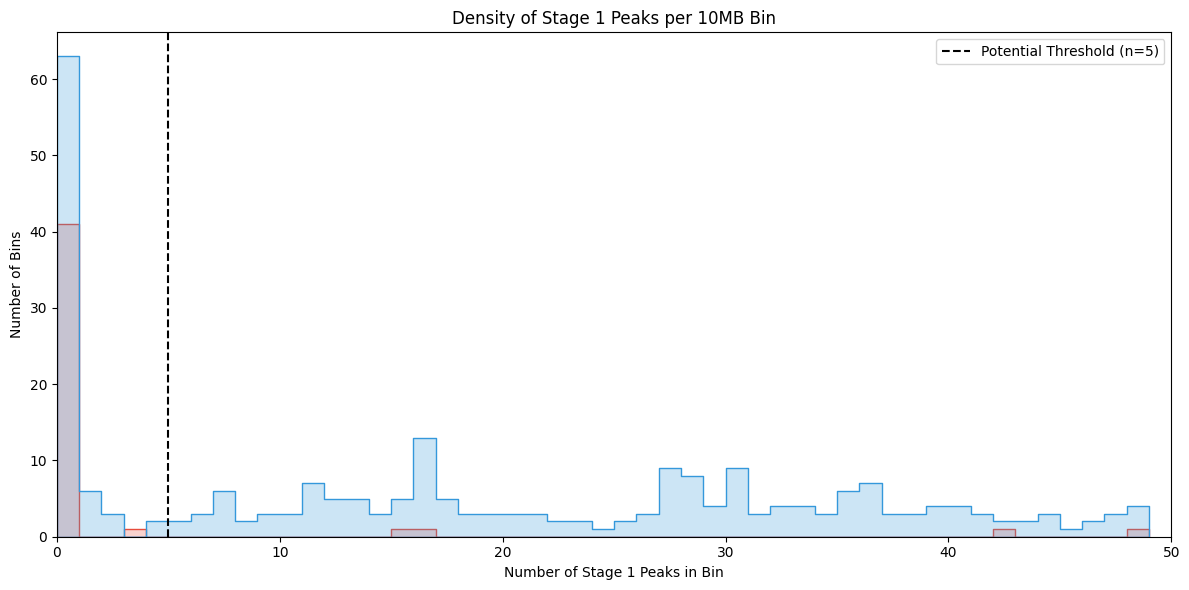


--- H3K27me3 Summary Stats ---
count    325.000000
mean      31.612308
std       30.522262
min        0.000000
25%        7.000000
50%       27.000000
75%       47.000000
max      181.000000
Name: peak_count, dtype: float64
Bins with 0 peaks: 63
Bins with < 5 peaks: 74

--- ATAC-seq Summary Stats ---
count     325.000000
mean      647.406154
std       421.933828
min         0.000000
25%       215.000000
50%       746.000000
75%       965.000000
max      1880.000000
Name: peak_count, dtype: float64
Bins with 0 peaks: 41
Bins with < 5 peaks: 42


In [ ]:
# ==============================================================================
# QC: PLOT PEAK DENSITY PER 1MB BIN
# ==============================================================================

# Ensure these match your actual file paths or the output from the merge step
s1_h3_file = merged_h3_files['Early RS']
s1_atac_file = merged_atac_files['Early RS']

# Define your chromosome sizes file and bin size
BIN_SIZE = 10000000 


# 1. Create the genomic windows
windows = pybedtools.BedTool().window_maker(g=chrom_sizes_file, w=BIN_SIZE)

def get_bin_counts(bed_file, mark_name):
    s1_bed = pybedtools.BedTool(bed_file)
    
    # Intersect with the -c flag to count peaks per window
    counts_df = windows.intersect(s1_bed, c=True).to_dataframe(names=['chrom', 'start', 'end', 'peak_count'])
    
    # Add a column for the mark so we can plot them together or side-by-side
    counts_df['Mark'] = mark_name
    return counts_df

# Get counts for both marks
df_h3_counts = get_bin_counts(s1_h3_file, 'H3K27me3')
df_atac_counts = get_bin_counts(s1_atac_file, 'ATAC-seq')

# Combine them for plotting
df_all_counts = pd.concat([df_h3_counts, df_atac_counts])

# ==============================================================================
# PLOTTING THE HISTOGRAM
# ==============================================================================

plt.figure(figsize=(12, 6))

# histogram with KDE (kernel density estimate) to see the distribution shape.
# limit the x-axis to zoom in on the relevant numbers (e.g., 0 to 50 peaks)
sns.histplot(
    data=df_all_counts, 
    x='peak_count', 
    hue='Mark', 
    element='step', 
    stat='count', 
    common_norm=False,
    bins=range(0, 50, 1), # Bins from 0 to 50 peaks (adjust if your density is higher!)
    palette={'H3K27me3': '#3498db', 'ATAC-seq': '#e74c3c'}
)

# Add a vertical line at a hypothetical threshold of 5 peaks
plt.axvline(x=5, color='black', linestyle='--', label='Potential Threshold (n=5)')

plt.title(f'Density of Stage 1 Peaks per {BIN_SIZE//1000000}MB Bin')
plt.xlabel('Number of Stage 1 Peaks in Bin')
plt.ylabel('Number of Bins')
plt.xlim(0, 50)
plt.legend()
plt.tight_layout()

# Save and show
plt.savefig('QC_Peak_Density_Histogram.pdf')
plt.show()

# Print some quick summary statistics to the console
print("\n--- H3K27me3 Summary Stats ---")
print(df_h3_counts['peak_count'].describe())
print(f"Bins with 0 peaks: {(df_h3_counts['peak_count'] == 0).sum()}")
print(f"Bins with < 5 peaks: {(df_h3_counts['peak_count'] < 5).sum()}")

print("\n--- ATAC-seq Summary Stats ---")
print(df_atac_counts['peak_count'].describe())
print(f"Bins with 0 peaks: {(df_atac_counts['peak_count'] == 0).sum()}")
print(f"Bins with < 5 peaks: {(df_atac_counts['peak_count'] < 5).sum()}")

Early RS to Late RS | Median Diff: 30.99% | p < 0.0001
Early RS to Early ES | Median Diff: 25.13% | p < 0.0001
Early RS to Int ES | Median Diff: 16.62% | p < 0.0001


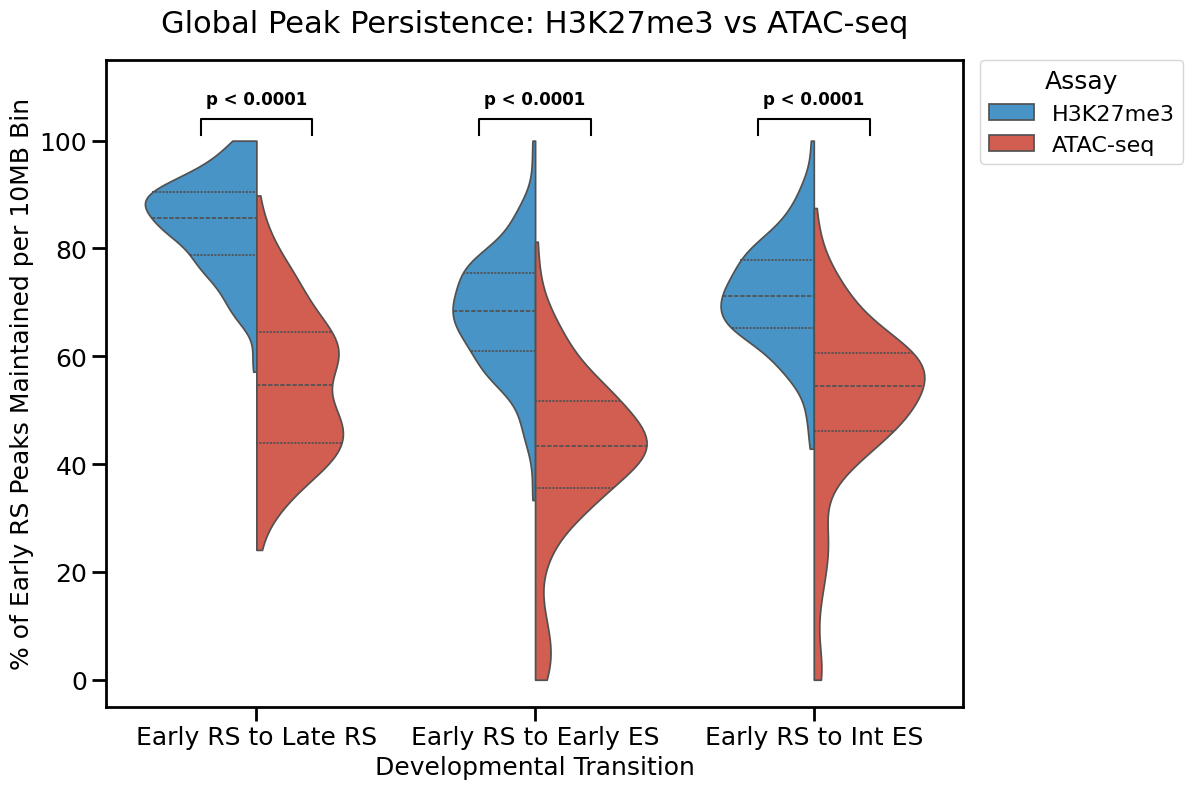

In [ ]:
# ==============================================================================
# 1. DEFINE THE PERMUTATION STATISTIC
# ==============================================================================
# We want to test the difference in medians between the two distributions
def median_diff(x, y, axis):
    return np.median(x, axis=axis) - np.median(y, axis=axis)

# ==============================================================================
# 2. CREATE THE PLOT
# ==============================================================================
plt.figure(figsize=(12, 8))

# Plot the split violin
ax = sns.violinplot(
    data=df_violin, 
    x='Stage', 
    y='Percent_Maintained', 
    hue='Mark', 
    split=True, 
    inner='quartile',
    cut=0,
    palette={'H3K27me3': '#3498db', 'ATAC-seq': '#e74c3c'}
)

# Customize basic plot aesthetics
plt.title('Global Peak Persistence: H3K27me3 vs ATAC-seq', fontsize=22, pad=20)
plt.ylabel('% of Early RS Peaks Maintained per 10MB Bin', fontsize=18)
plt.xlabel('Developmental Transition', fontsize=18)
plt.ylim(-5, 115)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Move legend outside plot and increase font size
plt.legend(
    title="Assay", 
    loc='upper left', 
    bbox_to_anchor=(1.02, 1), 
    borderaxespad=0, 
    fontsize=16, 
    title_fontsize=18
)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for legend


# Make ticks bigger, longer, and bolder
plt.tick_params(
    axis='both',        # apply to both axes
    which='major',      # major ticks
    labelsize=18,       # font size for tick labels
    length=10,          # tick length
    width=2,            # tick width (bold)
    direction='out'     # ticks outside axes
)

# Make axis lines bolder
for spine in ax.spines.values():
    spine.set_linewidth(2)


# ==============================================================================
# 3. RUN PERMUTATION TESTS & DRAW ANNOTATIONS
# ==============================================================================
stages = df_violin['Stage'].unique()

for i, stage in enumerate(stages):
    # Extract the data for this specific stage (dropping any potential NaNs)
    h3_data = df_violin[(df_violin['Stage'] == stage) & (df_violin['Mark'] == 'H3K27me3')]['Percent_Maintained'].dropna()
    atac_data = df_violin[(df_violin['Stage'] == stage) & (df_violin['Mark'] == 'ATAC-seq')]['Percent_Maintained'].dropna()
    
    # Skip if data is missing
    if len(h3_data) == 0 or len(atac_data) == 0:
        continue
        
    # Run the Permutation Test for difference in medians (100,000 resamples)
    res = stats.permutation_test(
        data=(h3_data, atac_data), 
        statistic=median_diff, 
        vectorized=True, 
        n_resamples=99999, 
        alternative='two-sided'
    )
    p_val = res.pvalue
    
    # Format the exact p-value for the plot
    if p_val < 0.0001:
        p_text = "p < 0.0001"
    else:
        p_text = f"p = {p_val:.4f}"
        
    # --- Drawing the Annotations ---
    # Find the maximum y-value for this specific stage to place the bracket just above the violin
    max_y = max(h3_data.max(), atac_data.max())
    bracket_y = max_y + 1   # Height of the bracket base
    bracket_h = 3           # Height of the bracket prongs
    
    # X coordinates for the left (H3) and right (ATAC) sides of the split violin
    # We shift slightly left (-0.2) and right (+0.2) from the center index `i`
    x1, x2 = i - 0.2, i + 0.2
    
    # Draw the bracket line: Left prong up, across, right prong down
    plt.plot([x1, x1, x2, x2], [bracket_y, bracket_y+bracket_h, bracket_y+bracket_h, bracket_y], lw=1.5, color='black')
    
    # Add the p-value text precisely centered above the bracket
    plt.text(
        (x1 + x2) * 0.5,           # Center X
        bracket_y + bracket_h + 2, # Slightly above the bracket Y
        p_text, 
        ha='center', 
        va='bottom', 
        color='black', 
        fontsize=12,
        fontweight='bold'
    )
    
    # Optional: Print to console for your lab notebook
    print(f"{stage} | Median Diff: {res.statistic:.2f}% | {p_text}")

# ==============================================================================
# 4. FINALIZE AND SAVE
# ==============================================================================
plt.tight_layout()
plt.savefig('figure_plots/Persistence_Violin_PermutationAnnotated.png', format='png', dpi=300)
plt.show()

In [8]:
df_violin

,Stage,Percent_Maintained,Mark
0,Early RS to Late RS,87.500000,H3K27me3
1,Early RS to Late RS,78.571429,H3K27me3
2,Early RS to Late RS,81.250000,H3K27me3
3,Early RS to Late RS,87.804878,H3K27me3
4,Early RS to Late RS,76.470588,H3K27me3
...,...,...,...
278,Early RS to Int ES,47.959184,ATAC-seq
279,Early RS to Int ES,57.636122,ATAC-seq
280,Early RS to Int ES,60.018639,ATAC-seq
281,Early RS to Int ES,56.590909,ATAC-seq


/tmp/ipykernel_2831543/3116953915.py:53: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



Late RS | Median Diff: 30.99% | p < 0.0001
Early ES | Median Diff: 25.13% | p < 0.0001
Int ES | Median Diff: 16.62% | p < 0.0001


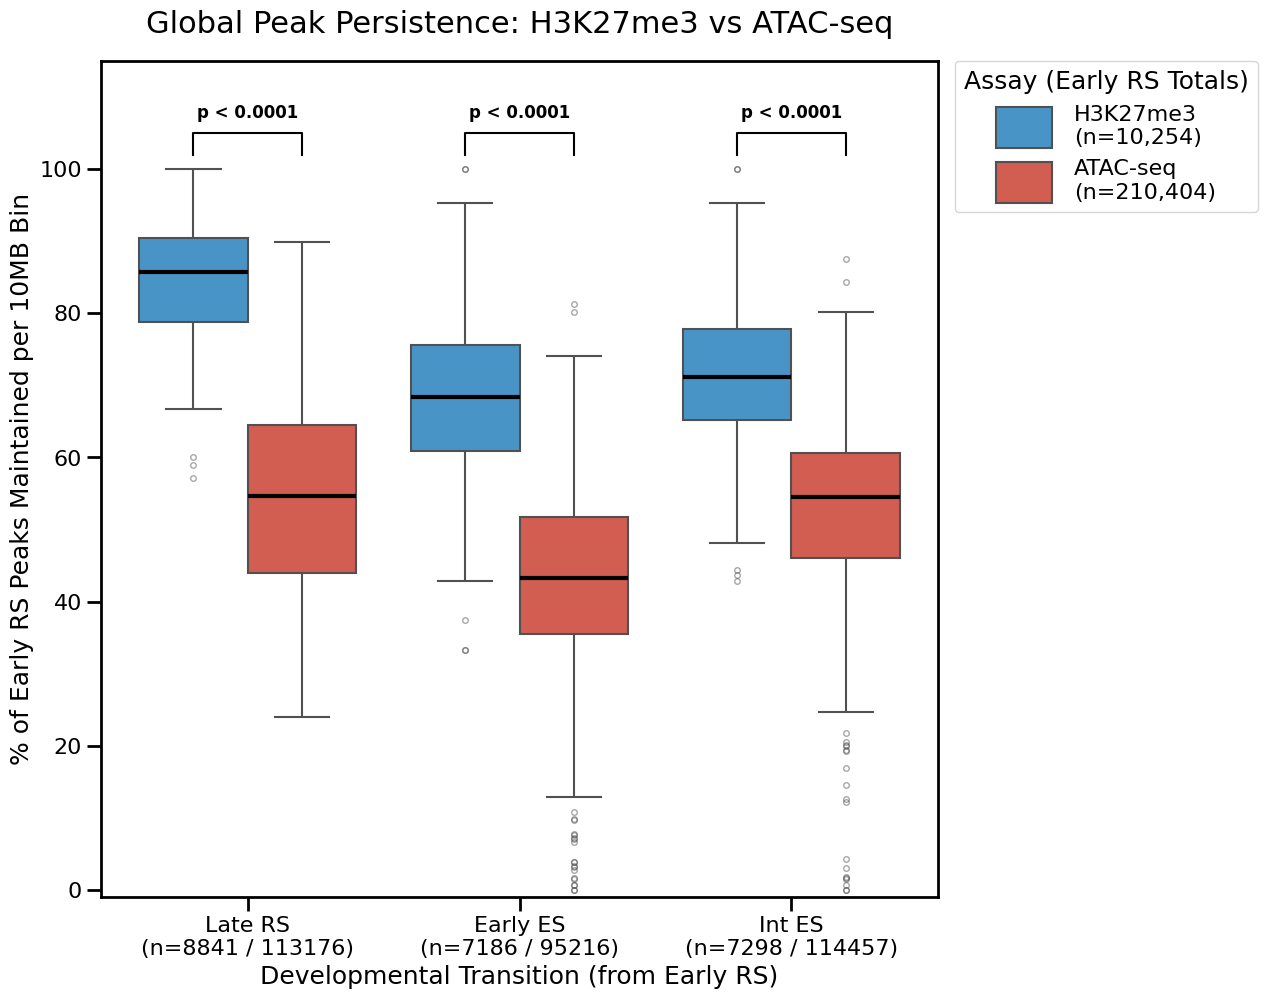

In [ ]:
# boxplot
# ==============================================================================
# 1. DEFINE THE PERMUTATION STATISTIC
# ==============================================================================
# We want to test the difference in medians between the two distributions
def median_diff(x, y, axis):
    return np.median(x, axis=axis) - np.median(y, axis=axis)

# ==============================================================================
# 2. CREATE THE PLOT
# ==============================================================================
plt.figure(figsize=(15, 10))

# Plot the side-by-side boxplots
# medianprops is used here to make the median line bold and black
ax = sns.boxplot(
    data=df_violin, 
    x='Stage', 
    y='Percent_Maintained', 
    hue='Mark', 
    palette={'H3K27me3': '#3498db', 'ATAC-seq': '#e74c3c'},
    width=0.8,
    linewidth=1.5,
    medianprops={'linewidth': 3, 'color': 'black'}, # Bolds the median
    flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5} # Styles the outliers
)

# Customize basic plot aesthetics
plt.title('Global Peak Persistence: H3K27me3 vs ATAC-seq', fontsize=22, pad=20)
plt.ylabel('% of Early RS Peaks Maintained per 10MB Bin', fontsize=18)
plt.xlabel('Developmental Transition (from Early RS)', fontsize=18)
plt.ylim(-1, 115) # slightly increased upper limit to ensure brackets fit above outliers

# --- Add Total Peak / Bin Counts to X-axis Labels ---
stages = df_violin['Stage'].unique()
new_labels = []

for stage in stages:
    # Get the data for this stage
    h3_stage_data = df_violin[(df_violin['Stage'] == stage) & (df_violin['Mark'] == 'H3K27me3')]
    atac_stage_data = df_violin[(df_violin['Stage'] == stage) & (df_violin['Mark'] == 'ATAC-seq')]
    
    # Calculate counts
    count_h3 = int(h3_stage_data['maintained_count'].sum())
    count_atac = int(atac_stage_data['maintained_count'].sum())
    
    # Append the counts to the stage name
    new_labels.append(f"{stage}\n(n={count_h3} / {count_atac})")

# Apply the new labels to the x-axis
ax.set_xticklabels(new_labels, fontsize=16)
plt.yticks(fontsize=16)

# ==============================================================================
# 1. Calculate the total s1 starting peaks for each mark. 
# We filter by just the first stage (stages[0]) to avoid double-counting 
# the Early RS bins that are repeated for each target stage in the dataframe.
s1_total_h3 = int(df_violin[(df_violin['Mark'] == 'H3K27me3') & (df_violin['Stage'] == stages[0])]['s1_count'].sum())
s1_total_atac = int(df_violin[(df_violin['Mark'] == 'ATAC-seq') & (df_violin['Stage'] == stages[0])]['s1_count'].sum())

# 2. Get the current legend elements (colors/shapes) drawn by seaborn
handles, previous_labels = ax.get_legend_handles_labels()

# 3. Create our new custom text labels, formatting the numbers with commas
legend_labels = [
    f"H3K27me3\n(n={s1_total_h3:,})", 
    f"ATAC-seq\n(n={s1_total_atac:,})"
]

# 4. Draw the customized legend outside the plot
plt.legend(
    handles=handles,
    labels=legend_labels,
    title="Assay (Early RS Totals)", 
    loc='upper left', 
    bbox_to_anchor=(1.02, 1), 
    borderaxespad=0, 
    fontsize=16, 
    title_fontsize=18,

    handlelength=2.5,   # Makes the colored box wider (default is ~2)
    handleheight=2.5,   # Makes the colored box taller (default is ~0.7)
    handletextpad=1.0   # Adds a little extra space between the big box and your text
)

plt.tight_layout(rect=[0, 0, 0.85, 1])


# Make ticks bigger, longer, and bolder
plt.tick_params(
    axis='both',        
    which='major',      
    labelsize=16,       
    length=10,          
    width=2,            
    direction='out'     
)

# Make axis lines bolder
for spine in ax.spines.values():
    spine.set_linewidth(2)

# ==============================================================================
# 3. RUN PERMUTATION TESTS & DRAW ANNOTATIONS
# ==============================================================================
for i, stage in enumerate(stages):
    # Extract the data for this specific stage
    h3_data = df_violin[(df_violin['Stage'] == stage) & (df_violin['Mark'] == 'H3K27me3')]['Percent_Maintained'].dropna()
    atac_data = df_violin[(df_violin['Stage'] == stage) & (df_violin['Mark'] == 'ATAC-seq')]['Percent_Maintained'].dropna()
    
    # Skip if data is missing
    if len(h3_data) == 0 or len(atac_data) == 0:
        continue
        
    # Run the Permutation Test
    res = stats.permutation_test(
        data=(h3_data, atac_data), 
        statistic=median_diff, 
        vectorized=True, 
        n_resamples=99999, 
        alternative='two-sided'
    )
    p_val = res.pvalue
    
    if p_val < 0.0001:
        p_text = "p < 0.0001"
    else:
        p_text = f"p = {p_val:.4f}"
        
    # --- Drawing the Annotations ---
    # Find the maximum y-value to place the bracket just above the highest boxplot outlier
    max_y = max(h3_data.max(), atac_data.max())
    bracket_y = max_y + 2   # Height of the bracket base (adjusted slightly for boxplots)
    bracket_h = 3           # Height of the bracket prongs
    
    # X coordinates for side-by-side boxplots (hue dodge is usually 0.4 wide per pair)
    x1, x2 = i - 0.2, i + 0.2
    
    # Draw the bracket line
    plt.plot([x1, x1, x2, x2], [bracket_y, bracket_y+bracket_h, bracket_y+bracket_h, bracket_y], lw=1.5, color='black')
    
    # Add the p-value text precisely centered above the bracket
    plt.text(
        (x1 + x2) * 0.5,           
        bracket_y + bracket_h + 1.5, 
        p_text, 
        ha='center', 
        va='bottom', 
        color='black', 
        fontsize=12,
        fontweight='bold'
    )
    
    print(f"{stage} | Median Diff: {res.statistic:.2f}% | {p_text}")

# ==============================================================================
# 4. FINALIZE AND SAVE
# ==============================================================================
plt.savefig('figure_plots/Persistence_Boxplot_PermutationAnnotated.png', format='png', dpi=300)
plt.show()

In [ ]:
def generate_dynamic_sankey(files_dict, mark_name, main_color):
    
    # 1. Load the immutable anchor peaks (Stage 1)
    s1_bed = pybedtools.BedTool(files_dict['Early RS'])
    
    print(f"[{mark_name}] Calculating state-to-state transitions...")
    s2_counts = s1_bed.intersect(files_dict['Late RS'], c=True).to_dataframe().iloc[:, -1]
    s3_counts = s1_bed.intersect(files_dict['Early ES'], c=True).to_dataframe().iloc[:, -1]
    s4_counts = s1_bed.intersect(files_dict['Int ES'], c=True).to_dataframe().iloc[:, -1]
    
    # 2. Build the Presence/Absence Matrix
    df_flows = pd.DataFrame({
        'S1': 1,
        'S2': (s2_counts > 0).astype(int),
        'S3': (s3_counts > 0).astype(int),
        'S4': (s4_counts > 0).astype(int)
    })
    
    # ==========================================================================
    # NODE & LINK SETUP
    # ==========================================================================
    
    labels = [
        "Early RS",                # 0
        "Late RS (Present)",       # 1
        "Late RS (Absent)",        # 2
        "Early ES (Present)",      # 3
        "Early ES (Absent)",       # 4
        "Int ES (Present)",        # 5
        "Int ES (Absent)"          # 6
    ]
    
    # By strictly anchoring 'Present' nodes at y=0.1 and 'Absent' at y=0.9,
    # Plotly is mathematically forced to stack the bands in perfect order.
    x_coords = [0.01, 0.33, 0.33, 0.66, 0.66, 0.99, 0.99]
    y_coords = [0.1,  0.1,  0.9,  0.1,  0.9,  0.1,  0.9]
    
    node_colors = [main_color, main_color, "#d3d3d3", main_color, "#d3d3d3", main_color, "#d3d3d3"]
    
    # Link Colors
    if mark_name == 'H3K27me3':
        color_maintained = "rgba(52, 152, 219, 0.5)"
    else:
        color_maintained = "rgba(231, 76, 60, 0.5)"
        
    color_lost = "rgba(200, 200, 200, 0.3)" 
    color_reappeared = "rgba(243, 156, 18, 0.6)" # A gold/orange highlight for rescued peaks
    
    # ==========================================================================
    # CALCULATE TRANSITIONS & ANNOTATIONS
    # ==========================================================================
    source = []
    target = []
    value = []
    link_colors = []
    annotations = [] # NEW: List to hold our static text labels

    transitions = [
        # --- Stage 1 to Stage 2 ---
        (0, 1, len(df_flows[df_flows['S2'] == 1]), color_maintained),
        (0, 2, len(df_flows[df_flows['S2'] == 0]), color_lost),
        
        # --- Stage 2 to Stage 3 ---
        (1, 3, len(df_flows[(df_flows['S2'] == 1) & (df_flows['S3'] == 1)]), color_maintained),
        (1, 4, len(df_flows[(df_flows['S2'] == 1) & (df_flows['S3'] == 0)]), color_lost),
        (2, 3, len(df_flows[(df_flows['S2'] == 0) & (df_flows['S3'] == 1)]), color_reappeared),
        (2, 4, len(df_flows[(df_flows['S2'] == 0) & (df_flows['S3'] == 0)]), color_lost),
        
        # --- Stage 3 to Stage 4 ---
        (3, 5, len(df_flows[(df_flows['S3'] == 1) & (df_flows['S4'] == 1)]), color_maintained),
        (3, 6, len(df_flows[(df_flows['S3'] == 1) & (df_flows['S4'] == 0)]), color_lost),
        (4, 5, len(df_flows[(df_flows['S3'] == 0) & (df_flows['S4'] == 1)]), color_reappeared),
        (4, 6, len(df_flows[(df_flows['S3'] == 0) & (df_flows['S4'] == 0)]), color_lost)
    ]
    
    # Calculate node totals to append to labels
    node_totals = [0] * len(labels)
    node_totals[0] = len(df_flows) # Stage 1 is the total anchor


    # ==========================================================================
    # DYNAMIC NODE HEIGHT & STACKING PRE-CALCULATION
    # ==========================================================================
    # Calculate the total volume of every node to determine its physical height
    node_in = [0] * len(labels)
    node_out = [0] * len(labels)
    for src, tgt, val, col in transitions:
        node_out[src] += val
        node_in[tgt] += val
        
    node_sizes = [max(i, o) for i, o in zip(node_in, node_out)]
    max_size = max(node_sizes)

    # Plotly leaves a little room for padding. 
    # 0.8 is a safe estimate for the usable vertical space (0.0 to 1.0).
    usable_y_space = 0.80
    units_to_y = usable_y_space / max_size

    # Group flows to calculate their exact stacking order within each node
    src_stacks = {i: [] for i in range(len(labels))}
    tgt_stacks = {i: [] for i in range(len(labels))}

    for src, tgt, val, col in transitions:
        src_stacks[src].append({'tgt': tgt, 'val': val})
        tgt_stacks[tgt].append({'src': src, 'val': val})

    # Sort flows the exact way Plotly does (by the destination/origin Y coordinate)
    for i in range(len(labels)):
        src_stacks[i] = sorted(src_stacks[i], key=lambda x: y_coords[x['tgt']])
        tgt_stacks[i] = sorted(tgt_stacks[i], key=lambda x: y_coords[x['src']])

    
    for src, tgt, val, col in transitions:
        if val > 0:
            source.append(src)
            target.append(tgt)
            value.append(val)
            link_colors.append(col)
            
            # Add to target node's total count
            node_totals[tgt] += val

            # ==========================================
            # DYNAMIC Y-START & Y-END
            # ==========================================
            
            # 1. Calculate the exact Y starting point on the Source node
            accum_out = 0
            for flow in src_stacks[src]:
                if flow['tgt'] == tgt:
                    break
                accum_out += flow['val']
            
            node_h_src = node_sizes[src] * units_to_y
            y_top_src = y_coords[src] - (node_h_src / 2)
            y_start = y_top_src + (accum_out + (val / 2)) * units_to_y
            
            # 2. Calculate the exact Y ending point on the Target node
            accum_in = 0
            for flow in tgt_stacks[tgt]:
                if flow['src'] == src:
                    break
                accum_in += flow['val']
                
            node_h_tgt = node_sizes[tgt] * units_to_y
            y_top_tgt = y_coords[tgt] - (node_h_tgt / 2)
            y_end = y_top_tgt + (accum_in + (val / 2)) * units_to_y

            # ==========================================
            # BEZIER CURVE & GAP PLACEMENT
            # ==========================================
            
            if y_coords[src] == y_coords[tgt]:
                gap_ratio = 0.5   # Maintained (Dead center)
            elif y_coords[src] < y_coords[tgt]:
                gap_ratio = 0.28  # Lost (Closer to Source)
            else:
                gap_ratio = 0.72  # Transient (Closer to Target)
                
            annot_x = x_coords[src] + (gap_ratio * (x_coords[tgt] - x_coords[src]))
            smooth_t = (gap_ratio ** 2) * (3 - 2 * gap_ratio)
            
            sankey_y = y_start + smooth_t * (y_end - y_start)
            annot_y = 1 - sankey_y

            # Append the annotation
            annotations.append(
                dict(
                    x=annot_x,
                    y=annot_y,
                    xref="paper",
                    yref="paper",
                    text=f"<b>n={val}</b>",
                    showarrow=False,
                    font=dict(size=11, color="black"),
                    bgcolor="rgba(255, 255, 255, 0.8)", 
                    bordercolor="black",
                    borderwidth=0.5,
                    xanchor="center",
                    yanchor="middle"
                )
            )

    
    # ==========================================================================
    # ADD COLUMN HEADERS (STAGE LABELS)
    # ==========================================================================
    #stage_names = ["Early RS", "Late RS", "Early ES", "Int ES"]
    #stage_x_coords = [0.01, 0.33, 0.66, 0.99] 
    flow_names = ["Early RS → Late RS", "Late RS → Early ES", "Early ES → Int ES"]
    flow_x_coords = [0.17, 0.495, 0.825]

    for name, x_pos in zip(flow_names, flow_x_coords):
        annotations.append(
            dict(
                x=x_pos,
                y=1.25, # Places the text above the nodes
                xref="paper",
                yref="paper",
                text=f"<b>{name}</b>",
                showarrow=False,
                font=dict(size=14, color="black"),
                xanchor="center",
                yanchor="bottom"
            )
        )

    # ==========================================================================
    # ADD NODE TOTALS INSIDE THE BOXES
    # ==========================================================================
    for i, count in enumerate(node_totals):
        # We use the exact same X and inverted Y coordinates as the nodes themselves
        annot_x = x_coords[i]
        annot_y = 1 - y_coords[i]
        
        annotations.append(
            dict(
                x=annot_x,
                y=annot_y,
                xref="paper",
                yref="paper",
                text=f"<b>n={count}</b>",
                showarrow=False,
                font=dict(size=12, color="black"), 
                # No background color here so it looks cleanly printed on the node
                xanchor="center",
                yanchor="middle"
            )
        )

    
    # ==========================================================================
    # RENDER PLOT WITH DUMMY LEGEND TRACES
    # ==========================================================================
    
    # Create the Sankey trace
    sankey_trace = go.Sankey(
        node = dict(
          pad = 20,
          thickness = 75, # <--- INCREASE THIS so the text fits inside
          line = dict(color = "black", width = 0.5),
          label = ["" for _ in range(len(node_totals))], # <--- BLANK OUT DEFAULT LABELS
          color = node_colors,
          x = x_coords,
          y = y_coords
        ),
        link = dict(
          source = source,
          target = target,
          value = value,
          color = link_colors
        )
    )

    # Create dummy scatter traces to force a legend
    dummy_maintained = go.Scatter(
        x=[None], y=[None], mode='markers', 
        marker=dict(size=12, color=main_color), 
        name='Maintained'
    )
    dummy_lost = go.Scatter(
        x=[None], y=[None], mode='markers', 
        marker=dict(size=12, color="#d3d3d3"), 
        name='Lost'
    )
    dummy_reappeared = go.Scatter(
        x=[None], y=[None], mode='markers', 
        marker=dict(size=12, color="rgba(243, 156, 18, 0.8)"), 
        name='Transient Rescue'
    )

    # Combine into one figure
    fig = go.Figure(data=[sankey_trace, dummy_maintained, dummy_lost, dummy_reappeared])
    
    fig.update_layout(
        # --- 1. PROPER TITLE POSITIONING ---
        title=dict(
            text=f"<b>{mark_name} Chromatin Dynamics</b>",
            y=0.98,      # Pushes the title to the very top of the figure area
            x=0.5,       # Centers the title horizontally
            xanchor='center',
            yanchor='top'
        ),
        font=dict(size=14, color="black"),
        plot_bgcolor='white',
        paper_bgcolor='white',
        width=1000,
        height=500,
        
        # --- 2. ADD TOP PADDING (MARGIN) ---
        # t = top, b = bottom, l = left, r = right
        # Increasing 't' gives your title and column annotations plenty of breathing room!
        margin=dict(t=150, b=40, l=40, r=50),
        annotations=annotations,
        xaxis=dict(visible=False), 
        yaxis=dict(visible=False),
        
        legend=dict(
            yanchor="top",
            y=0.99,       # Shifted slightly down so it doesn't hit the top margin
            xanchor="left",
            x=1.05,
            bgcolor="rgba(255, 255, 255, 0.9)",
            bordercolor="black",
            borderwidth=1
        ),
        showlegend=True
    )
    
    return fig

# Run the dynamic plots
fig_h3 = generate_dynamic_sankey(merged_h3_files, 'H3K27me3', '#3498db') 
fig_atac = generate_dynamic_sankey(merged_atac_files, 'ATAC-seq', '#e74c3c') 

fig_h3.show()
fig_atac.show()

[H3K27me3] Calculating state-to-state transitions...
[ATAC-seq] Calculating state-to-state transitions...


In [ ]:
# necessary to save the images in a non-interactive environment 
!plotly_get_chrome -y

Installing Chrome for Plotly...
Chrome installed successfully.
The Chrome executable is now located at: /home/zapell/.conda/envs/chromhmm_py39/lib/python3.9/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome


In [52]:
fig_h3.write_image("figure_plots/H3K27me3_Chromatin_Dynamics.png", scale=3)
fig_atac.write_image("figure_plots/ATAC_seq_Chromatin_Dynamics.png", scale=3)